# Deep Learning Course
## Prof. Sandro Camargo <sandrocamargo@unipampa.edu.br>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- Definição das Funções de Ativação ---

def leakyrelu(x, y):
    return np.where(x >= 0, x, y * x)

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(par):
    # Tradução fiel da lógica de soma log-exp estável do R
    n_par = len(par)
    par1 = np.sort(par)[::-1]  # Ordena em ordem decrescente
    Lk = par1[0]
    for k in range(n_par - 1):
        Lk = max(par1[k+1], Lk) + np.log1p(np.exp(-np.abs(par1[k+1] - Lk)))

    val = np.exp(par - Lk)
    return val

def softplus(x):
    return np.log(1 + np.exp(x))

def swish(x, beta):
    sig = 1 / (1 + np.exp(-beta * x))
    return x * sig

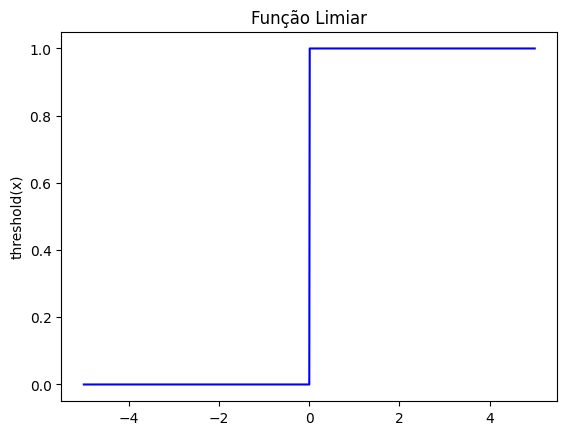

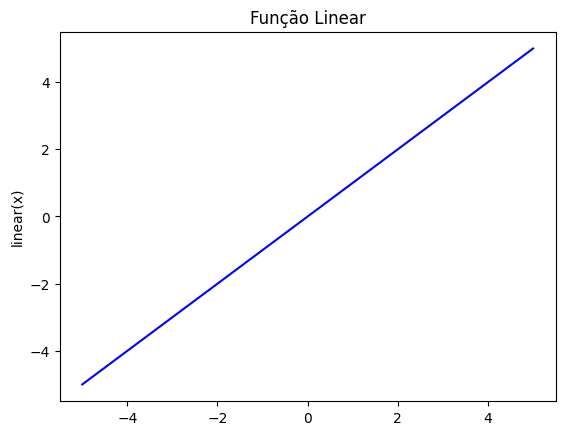

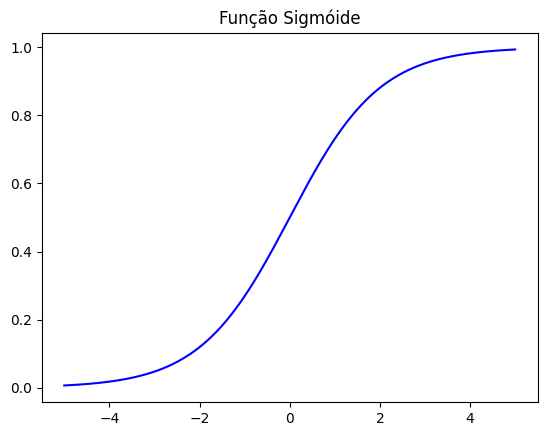

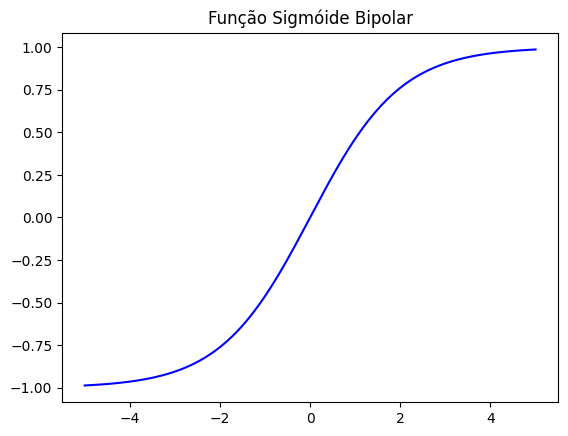

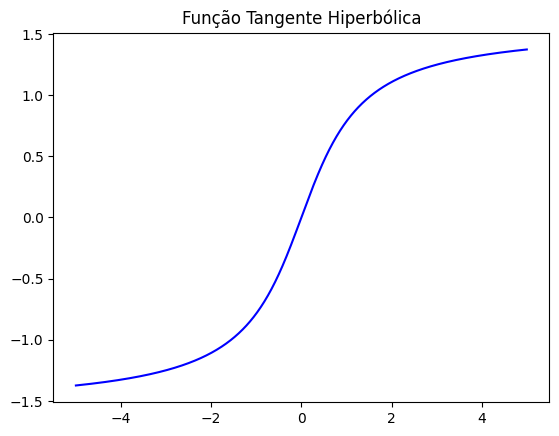

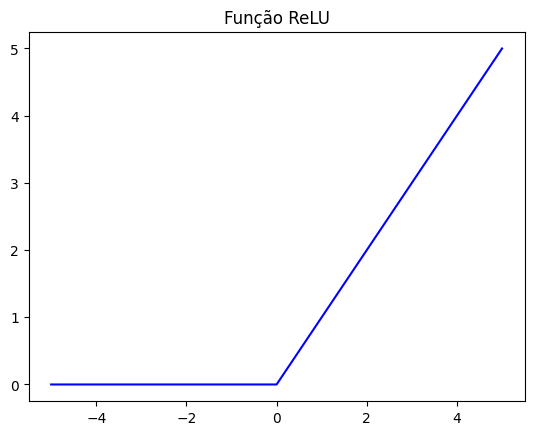

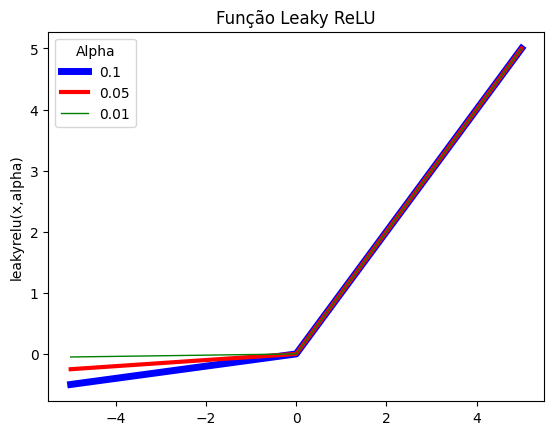

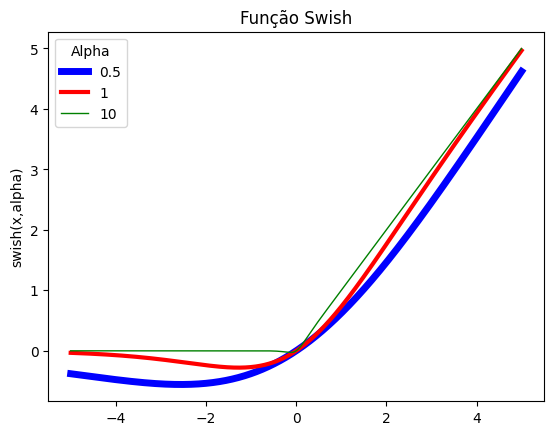

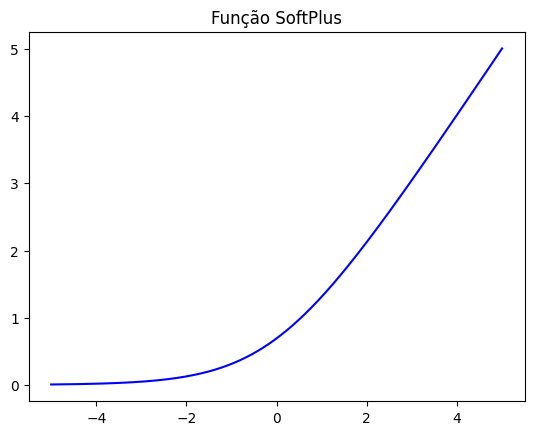

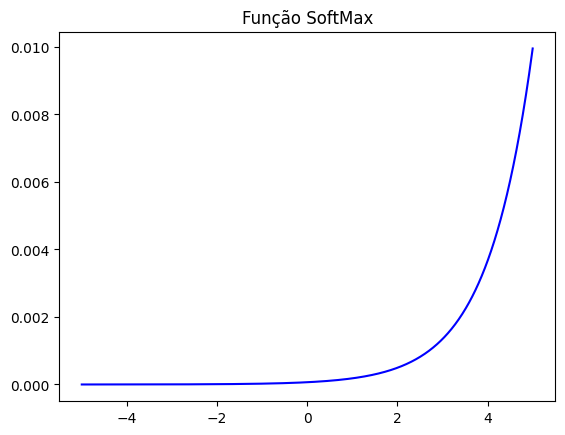

In [7]:
# --- Configuração do Ambiente e Variáveis ---

# Define o diretório de trabalho (ajuste o caminho se necessário)
# os.chdir(os.path.expanduser("~/Documents/unipampa/tcc/2019gabriel"))

x = np.arange(-5, 5.01, 0.01)

# --- Gerando Gráficos Individuais em PDF ---

# Função Limiar
y = np.where(x <= 0, 0, 1)
plt.figure()
plt.plot(x, y, color='blue')
plt.title("Função Limiar")
plt.ylabel("threshold(x)")
plt.savefig('activation-limiar.pdf')
plt.show()
plt.close()

# Função Linear
plt.figure()
plt.plot(x, x, color='blue')
plt.title("Função Linear")
plt.ylabel("linear(x)")
plt.savefig('activation-linear.pdf')
plt.show()
plt.close()

# Função Sigmóide
plt.figure()
plt.plot(x, sigmoid(x), color='blue')
plt.title("Função Sigmóide")
plt.savefig('activation-sigmoid.pdf')
plt.show()
plt.close()

# Função Sigmóide Bipolar
plt.figure()
plt.plot(x, sigmoid(x) * 2 - 1, color='blue')
plt.title("Função Sigmóide Bipolar")
plt.savefig('activation-sigmoid-bipolar.pdf')
plt.show()
plt.close()

# Função Tangente Hiperbólica (no script original R foi usado atan/Arcotangente)
plt.figure()
plt.plot(x, np.arctan(x), color='blue')
plt.title("Função Tangente Hiperbólica")
plt.savefig('activation-tanh.pdf')
plt.show()
plt.close()

# Função ReLU
plt.figure()
plt.plot(x, relu(x), color='blue')
plt.title("Função ReLU")
plt.savefig('activation-relu.pdf')
plt.show()
plt.close()

# Função Leaky ReLU
plt.figure()
plt.plot(x, leakyrelu(x, 0.1), color='blue', linewidth=5, label='0.1')
plt.plot(x, leakyrelu(x, 0.05), color='red', linewidth=3, label='0.05')
plt.plot(x, leakyrelu(x, 0.01), color='green', linewidth=1, label='0.01')
plt.title("Função Leaky ReLU")
plt.ylabel("leakyrelu(x,alpha)")
plt.legend(title="Alpha", loc="upper left")
plt.savefig('activation-leakyrelu.pdf')
plt.show()
plt.close()

# Função Swish
plt.figure()
plt.plot(x, swish(x, 0.5), color='blue', linewidth=5, label='0.5')
plt.plot(x, swish(x, 1.0), color='red', linewidth=3, label='1')
plt.plot(x, swish(x, 10.0), color='green', linewidth=1, label='10')
plt.title("Função Swish")
plt.ylabel("swish(x,alpha)")
plt.legend(title="Alpha", loc="upper left")
plt.savefig('activation-swish.pdf')
plt.show()
plt.close()

# Função SoftPlus
plt.figure()
plt.plot(x, softplus(x), color='blue')
plt.title("Função SoftPlus")
plt.savefig('activation-softplus.pdf')
plt.show()
plt.close()

# Função SoftMax
plt.figure()
plt.plot(x, softmax(x), color='blue')
plt.title("Função SoftMax")
plt.savefig('activation-softmax.pdf')
plt.show()
plt.close()

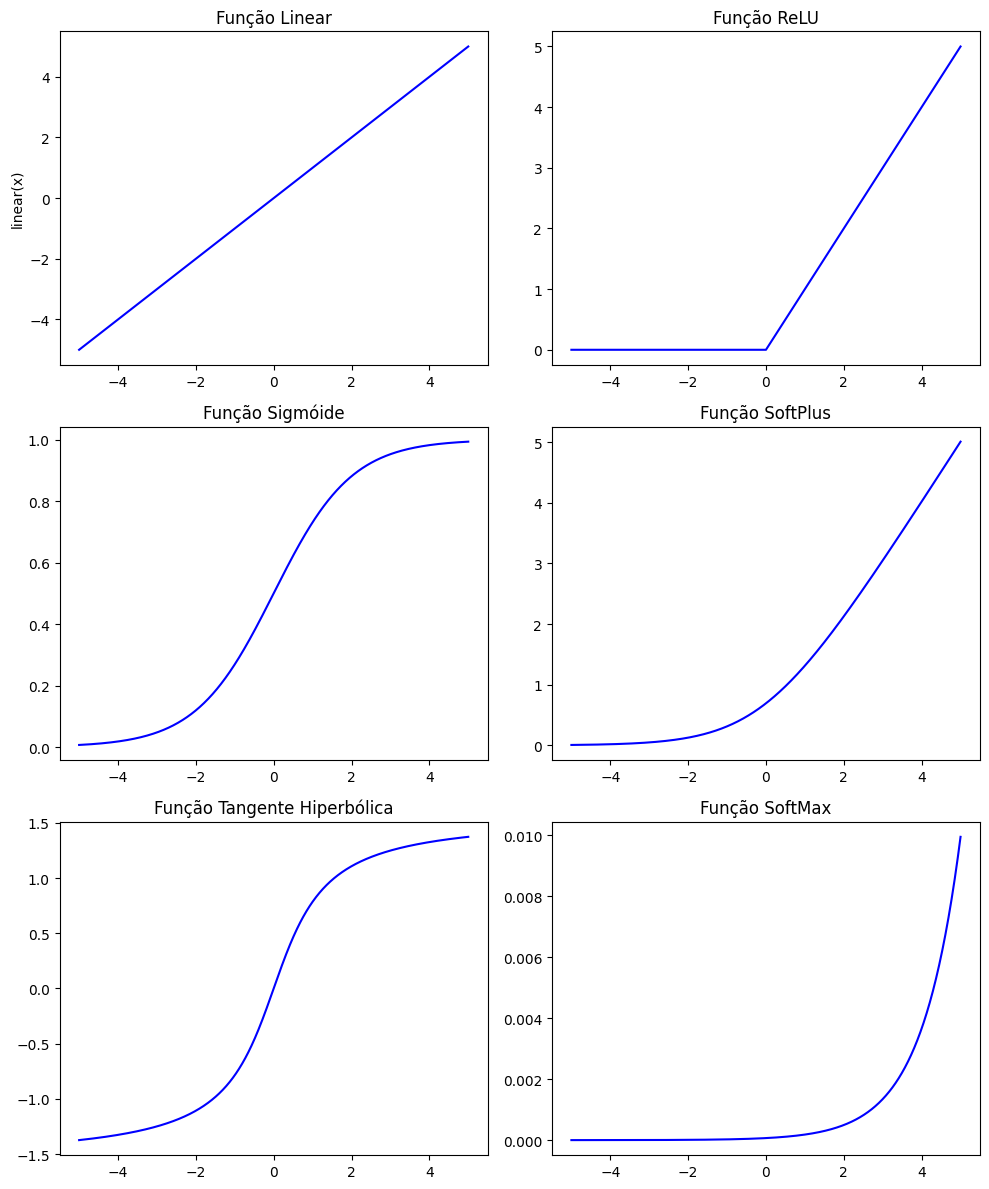

In [6]:
# --- Gráfico Composto (3 linhas x 2 colunas) ---

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

axes[0, 0].plot(x, x, color='blue')
axes[0, 0].set_title("Função Linear")
axes[0, 0].set_ylabel("linear(x)")

axes[1, 0].plot(x, sigmoid(x), color='blue')
axes[1, 0].set_title("Função Sigmóide")

axes[2, 0].plot(x, np.arctan(x), color='blue')
axes[2, 0].set_title("Função Tangente Hiperbólica")

axes[0, 1].plot(x, relu(x), color='blue')
axes[0, 1].set_title("Função ReLU")

axes[1, 1].plot(x, softplus(x), color='blue')
axes[1, 1].set_title("Função SoftPlus")

axes[2, 1].plot(x, softmax(x), color='blue')
axes[2, 1].set_title("Função SoftMax")

plt.tight_layout()
plt.savefig('activations.pdf')
plt.show()
plt.close()